In [1]:
# Cella 1: importazione librerie


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import pandas as pd
import matplotlib.pyplot as plt

# Impostazione dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [12]:
# Cella 2: Parametri del modello

# --- PARAMETRI FISICI ---
# Radionuclide di esempio: Lutezio-177 (177Lu)
T_half = 160.8  # Emivita fisica in ore (~6.7 giorni)
lmbda = np.log(2) / T_half   

# --- PARAMETRI CINETICI ---
# Costanti di velocità e parametri di Michaelis-Menten
k0 = 1.0        # Costante di dissociazione/stacco koff (h^-1)
k1 = 0.04       # Costante di associazione kon (h^-1 unit^-1)
Vmax = 12.0     # Velocità massima di internalizzazione (kBq/h) - Michaelis-Menten
Km = 50.0       # Costante di Michaelis per l'internalizzazione (kBq)
k3 = 0.001      # Costante di washout/efflux kout (h^-1)

# --- PARAMETRI DELLA COLTURA ---
Rtot = 100.0    # Quantità totale di recettori R_tot
A0 = 100.0      # Attività iniziale iniettata nel terreno Am(0) (kBq)

In [13]:
# Cella 3: Modello teorico ridotto a 3 compartimenti (Rfree algebrico)

def cellular_kinetic_system(t, y, lmbda, k0, k1, k3, Vmax, Km, Rtot):
    """
    Sistema ODE a 3 compartimenti con conservazione algebrica dei recettori:
    y = [Am, Ab, Aint]
    Rfree(t) = max(Rtot - Ab(t), 0)
    """
    Am, Ab, Aint = y
    Am = max(Am, 0.0)
    Ab = max(Ab, 0.0)
    Aint = max(Aint, 0.0)
    
    # Conservazione della massa dei recettori: Rfree(t) = Rtot - Ab(t)
    Rfree = max(Rtot - Ab, 0.0)
    
    # Flusso di internalizzazione saturabile (Michaelis-Menten)
    v_int = (Vmax * Ab) / (Km + Ab) if (Km + Ab) > 1e-12 else 0.0
    
    # Equazioni differenziali del sistema ridotto
    dAm   = -lmbda * Am - k1 * Rfree * Am + k0 * Ab + k3 * Aint
    dAb   =  k1 * Rfree * Am - (lmbda + k0) * Ab - v_int
    dAint =  v_int - (k3 + lmbda) * Aint
    
    return [dAm, dAb, dAint]

# Condizioni iniziali: Am(0)=A0, Ab(0)=0, Aint(0)=0
y0 = [A0, 0.0, 0.0]

# Intervallo temporale di simulazione (ore)
t_span = (0, 144)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Risoluzione del sistema ODE (metodo RK45)
sol = solve_ivp(
    cellular_kinetic_system, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(lmbda, k0, k1, k3, Vmax, Km, Rtot),
    method='RK45'
)

# Estrazione dei risultati
t = sol.t
Am, Ab, Aint = sol.y
Rfree = np.maximum(Rtot - Ab, 0.0)    # Recettori liberi calcolati algebricamente
A_cell_total = Ab + Aint               # Attività cellulare totale (membrana + internalizzata)
A_tot = Am + Ab + Aint

# Calcolo dell'Attività Cumulata A_tilde (integrale nel tempo)
cumulated_activity_cell = np.trapezoid(A_cell_total, t)  # in kBq·h

print("--------------------------------------------------")
print(f"Attività Cumulata Cellulare Integrata (0-{t_span[1]}h): {cumulated_activity_cell:.2f} kBq·h")
print("--------------------------------------------------")

--------------------------------------------------
Attività Cumulata Cellulare Integrata (0-144h): 10398.31 kBq·h
--------------------------------------------------


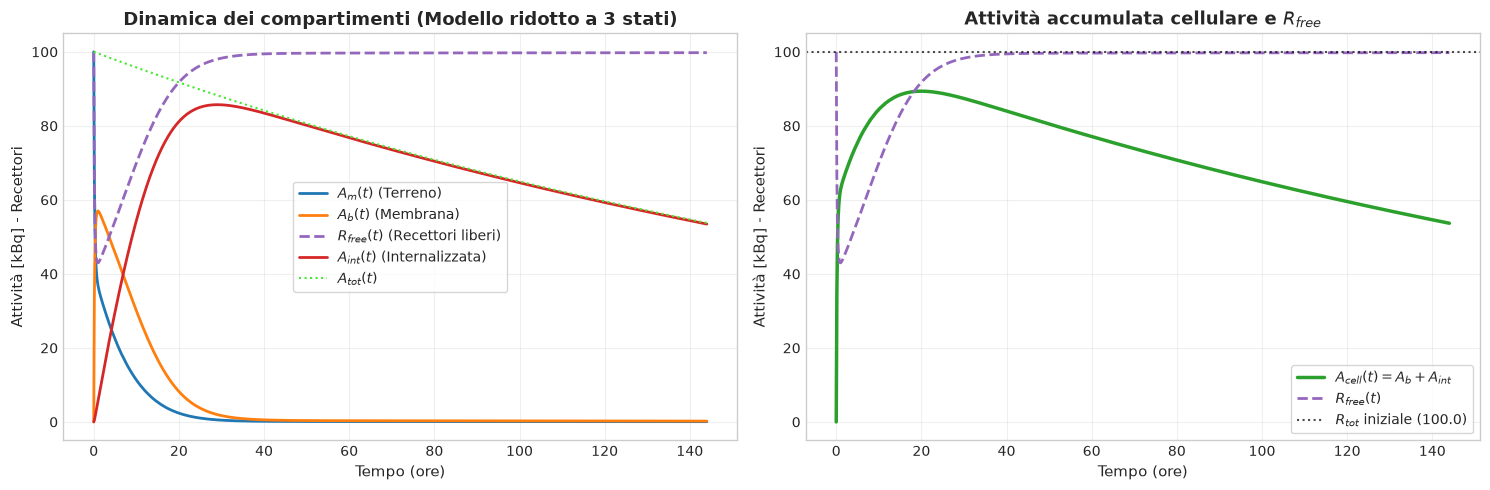

In [14]:
# Cella 4: Visualizzazione grafica

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Cinetica nei compartimenti
axes[0].plot(t, Am, label='$A_m(t)$ (Terreno)', color='#1f77b4', linewidth=2)
axes[0].plot(t, Ab, label='$A_b(t)$ (Membrana)', color='#ff7f0e', linewidth=2)
axes[0].plot(t, Rfree, label='$R_{free}(t)$ (Recettori liberi)', color='#9467bd', linestyle='--', linewidth=2)
axes[0].plot(t, Aint, label='$A_{int}(t)$ (Internalizzata)', color='#d62728', linewidth=2)
axes[0].plot(t, A_tot, label='$A_{tot}(t)$', color="#45e72f", linewidth=1.5, linestyle=':')
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività [kBq] - Recettori', fontsize=11)
axes[0].set_title('Dinamica dei compartimenti (Modello ridotto a 3 stati)', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Totale Cellulare e Recettori Liberi
axes[1].plot(t, A_cell_total, label='$A_{cell}(t) = A_b + A_{int}$', color='#2ca02c', linewidth=2.5)
axes[1].plot(t, Rfree, label='$R_{free}(t)$', color='#9467bd', linewidth=2, linestyle='--')
axes[1].axhline(y=Rtot, color='black', linestyle=':', alpha=0.7, label=f'$R_{{tot}}$ iniziale ({Rtot})')
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Attività [kBq] - Recettori', fontsize=11)
axes[1].set_title('Attività accumulata cellulare e $R_{free}$', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

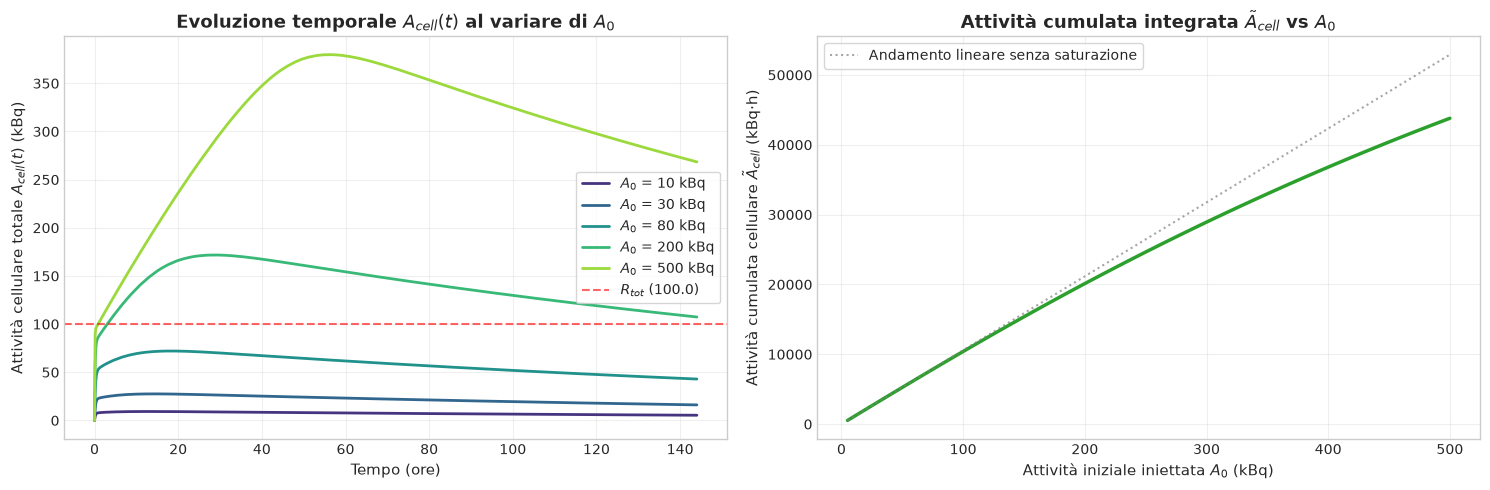

In [15]:
# Cella 5: Comportamento in funzione di A0

A0_range = np.linspace(5, 500, 60)  # Variazione di A0 da 5 a 500 kBq

cumulated_A_list = []
max_A_cell_list = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k3, Vmax, Km, Rtot),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # Ab (y[1]) + Aint (y[2])
    
    max_A_cell_list.append(np.max(A_cell_i))
    cumulated_A_list.append(np.trapezoid(A_cell_i, sol_i.t))

# --- VISUALIZZAZIONE GRAFICA ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Curve temporali A_cell(t) al variare di A0
A0_samples = [10, 30, 80, 200, 500]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(A0_samples)))

for A0_sample, color in zip(A0_samples, colors):
    sol_sample = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        [A0_sample, 0.0, 0.0], 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k3, Vmax, Km, Rtot),
        method='RK45'
    )
    A_cell_sample = sol_sample.y[1] + sol_sample.y[2]  # Ab + Aint
    axes[0].plot(sol_sample.t, A_cell_sample, label=f'$A_0$ = {A0_sample} kBq', color=color, linewidth=2)

axes[0].axhline(y=Rtot, color='red', linestyle='--', alpha=0.6, label=f'$R_{{tot}}$ ({Rtot})')
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività cellulare totale $A_{cell}(t)$ (kBq)', fontsize=11)
axes[0].set_title('Evoluzione temporale $A_{cell}(t)$ al variare di $A_0$', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Cumulata vs A0
axes[1].plot(A0_range, cumulated_A_list, color='#2ca02c', linewidth=2.5)
axes[1].set_xlabel('Attività iniziale iniettata $A_0$ (kBq)', fontsize=11)
axes[1].set_ylabel('Attività cumulata cellulare $\\tilde{A}_{cell}$ (kBq·h)', fontsize=11)
axes[1].set_title('Attività cumulata integrata $\\tilde{A}_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

linear_trend = cumulated_A_list[0] / A0_range[0] * A0_range
axes[1].plot(A0_range, linear_trend, color='gray', linestyle=':', alpha=0.7, label='Andamento lineare senza saturazione')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

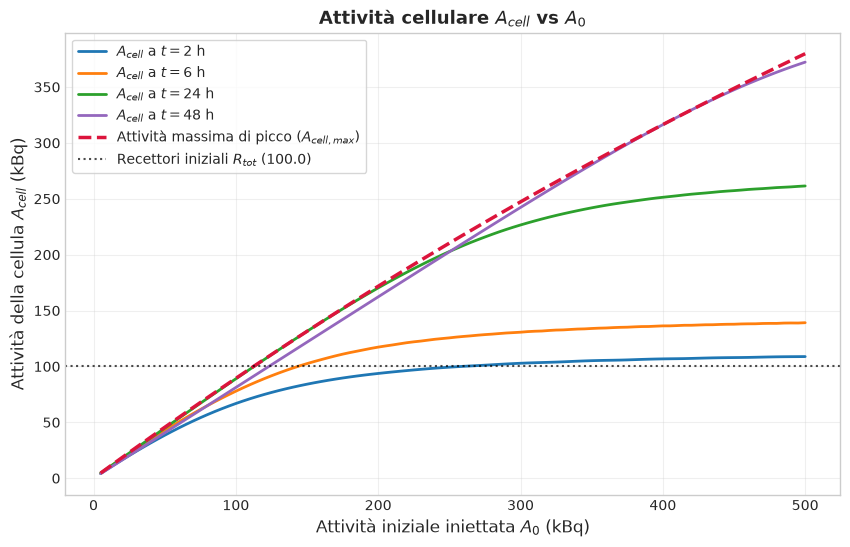

In [16]:
# Cella 6: A_cell vs A0

A0_range = np.linspace(5, 500, 100)
time_points = [2, 6, 24, 48]

A_cell_at_times = {t_val: [] for t_val in time_points}
A_cell_max = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k3, Vmax, Km, Rtot),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # Attività cellulare totale: Ab (y[1]) + Aint (y[2])
    
    for t_val in time_points:
        idx = np.argmin(np.abs(sol_i.t - t_val))
        A_cell_at_times[t_val].append(A_cell_i[idx])
        
    A_cell_max.append(np.max(A_cell_i))

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

for t_val, color in zip(time_points, colors):
    plt.plot(A0_range, A_cell_at_times[t_val], 
             label=f'$A_{{cell}}$ a $t = {t_val}$ h', 
             color=color, linewidth=2)

plt.plot(A0_range, A_cell_max, 
         label='Attività massima di picco ($A_{cell, max}$)', 
         color='crimson', linestyle='--', linewidth=2.5)

plt.axhline(y=Rtot, color='black', linestyle=':', alpha=0.7, 
            label=f'Recettori iniziali $R_{{tot}}$ ({Rtot})')

plt.xlabel('Attività iniziale iniettata $A_0$ (kBq)', fontsize=12)
plt.ylabel('Attività della cellula $A_{cell}$ (kBq)', fontsize=12)
plt.title('Attività cellulare $A_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

<>:244: SyntaxWarning: invalid escape sequence '\s'
<>:244: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1024583/14092461.py:244: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_ylabel('Residui Pesati $(y_{exp} - y_{pred}) / \sigma$', fontsize=11)


 RISULTATI FIT GLOBALE (Modello a 3 Stati Ridotto)
k0 (Dissociazione koff)        : 1.374294e+01 ± 1.143749e+01 h^-1
k1 (Associazione kon)          : 9.717444e-03 ± 3.455092e-03 h^-1 (kBq/mL)^-1
Vmax (Velocità max int.)       : 1.519455e-01 ± 1.113053e-02 (Bq/cell)/h
Km (Saturazione int.)          : 6.494856e-03 ± 2.127337e-06 Bq/cellula
k3 (Efflux/Riciclo kout)       : 8.512873e-01 ± 8.104188e-02 h^-1
R_free,0 (Radioattività t=0)  : 7.065316e-02 ± 1.494813e-02 Bq/cellula
--------------------------------------------------
 CONVERSIONE IN NUMERO DI RECETTORI FISICI
Attività Molare applicata      : 53.0 MBq/nmol
Fattore di conversione         : 1.1363e+07 molecole/Bq
R_free,0 (Recettori/cellula)   : 8.0280e+05 ± 1.6985e+05
--------------------------------------------------
Chi-quadro Ridotto             : 0.8798


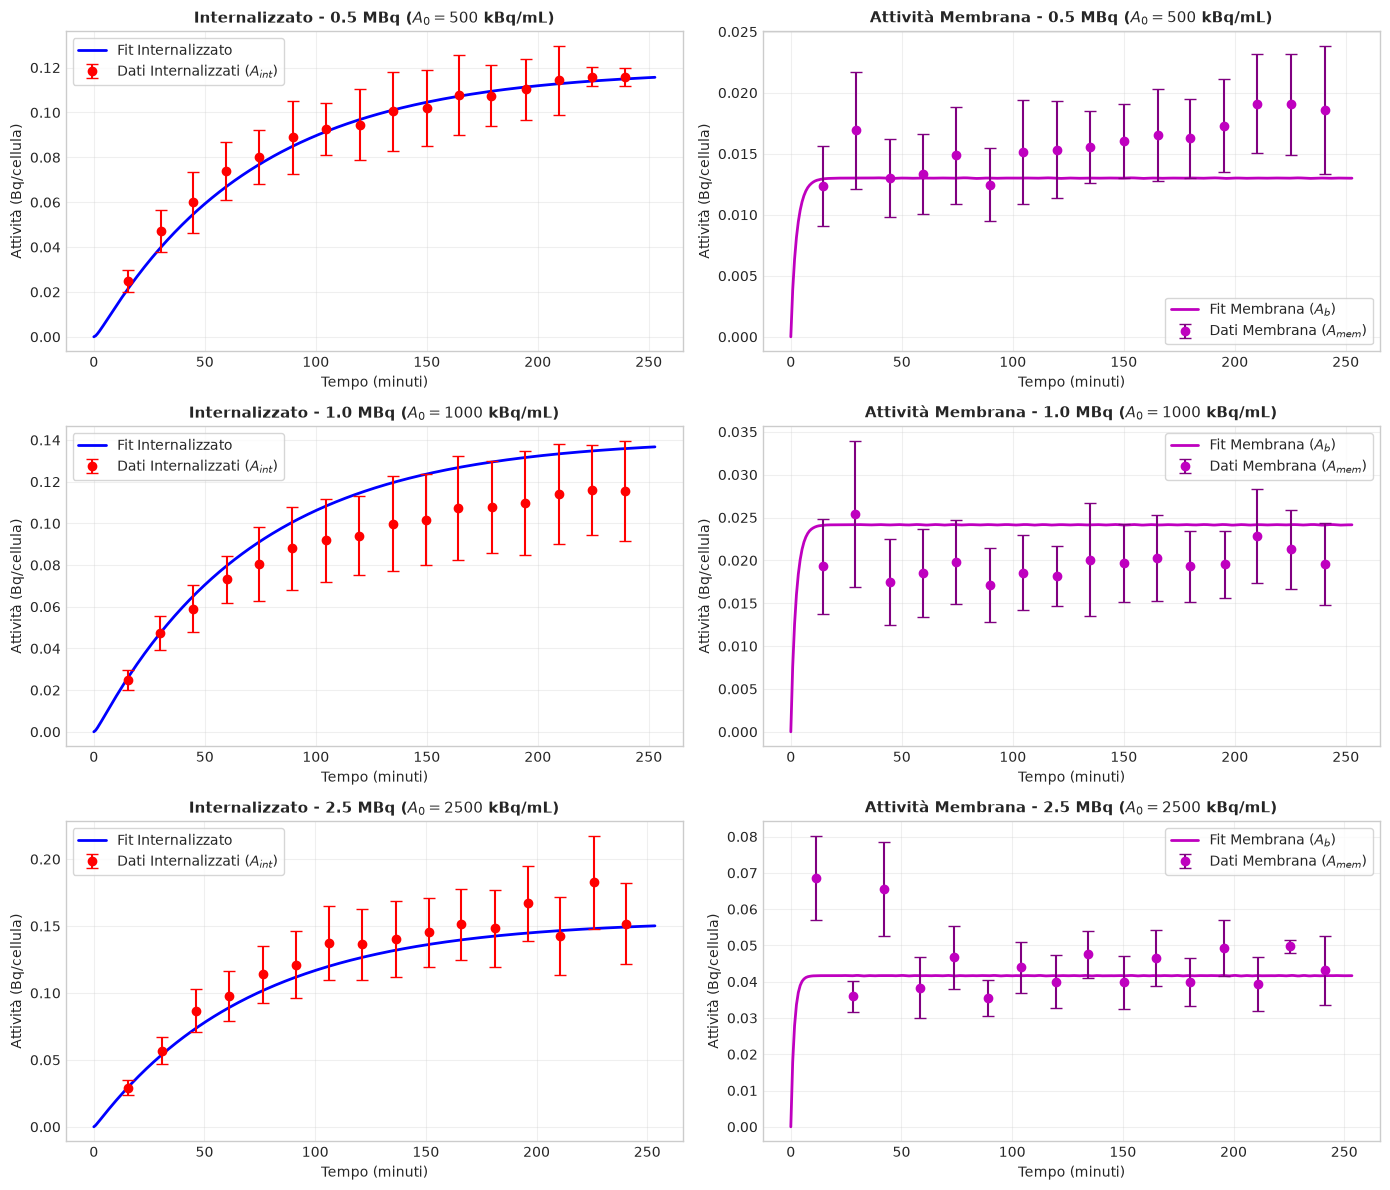

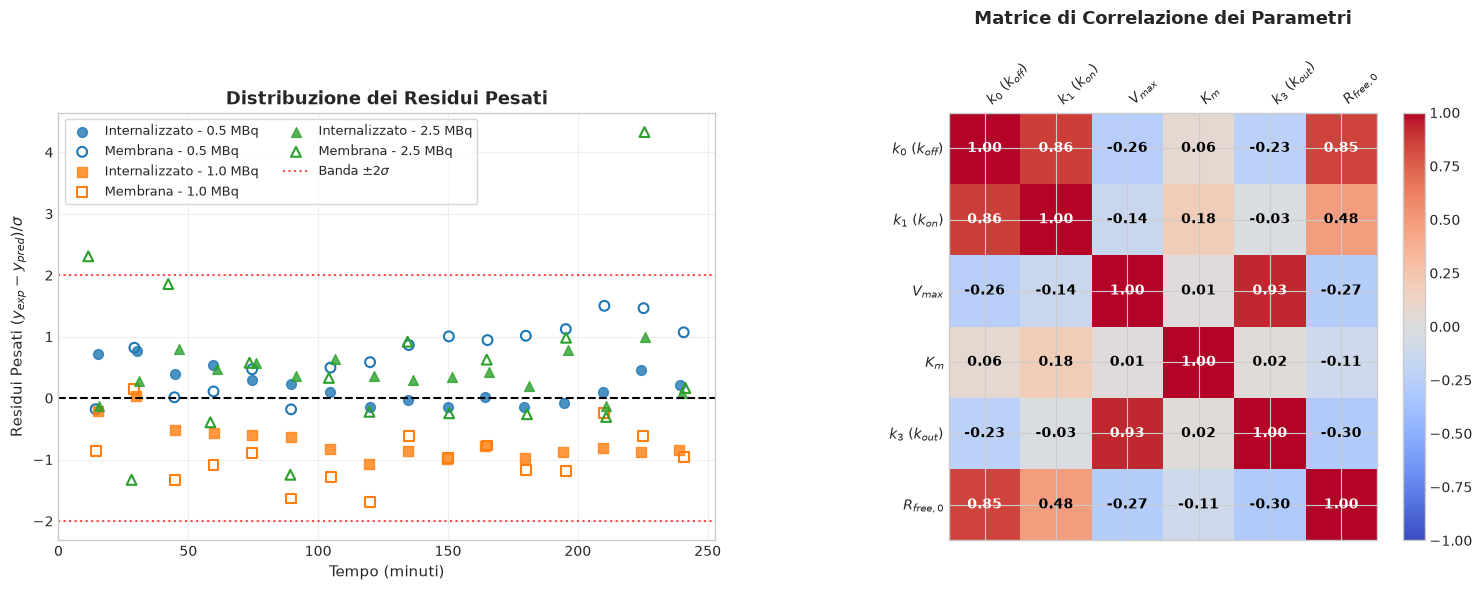

In [ ]:
# =============================================================================
# Cella 7: Fit dati
# =============================================================================

dataset_info = [
    {
        'label': '0.5 MBq',
        'A0': 500.0,
        'tot_val': 'cell_activity_05MBq_values.csv',
        'tot_err': 'cell_activity_05MBq_errors.csv',
        'mem_val': 'membrane_activity_05MBq_values.csv',
        'mem_err': 'membrane_activity_05MBq_errors.csv'
    },
    {
        'label': '1.0 MBq',
        'A0': 1000.0,
        'tot_val': 'cell_activity_1MBq_values.csv',
        'tot_err': 'cell_activity_1MBq_errors.csv',
        'mem_val': 'membrane_activity_1MBq_values.csv',
        'mem_err': 'membrane_activity_1MBq_errors.csv'
    },
    {
        'label': '2.5 MBq',
        'A0': 2500.0,
        'tot_val': 'cell_activity_25MBq_values.csv',
        'tot_err': 'cell_activity_25MBq_errors.csv',
        'mem_val': 'membrane_activity_25MBq_values.csv',
        'mem_err': 'membrane_activity_25MBq_errors.csv'
    }
]

exp_data = []

for ds in dataset_info:
    df_tot_data = pd.read_csv(ds['tot_val'], header=None)
    df_tot_err  = pd.read_csv(ds['tot_err'], header=None)
    t_min_tot   = df_tot_data.iloc[:, 0].values
    y_tot_exp   = df_tot_data.iloc[:, 1].values
    err_tot     = np.maximum(np.abs(df_tot_err.iloc[:, 1].values - y_tot_exp), 1e-8)
    
    df_mem_data = pd.read_csv(ds['mem_val'], header=None)
    df_mem_err  = pd.read_csv(ds['mem_err'], header=None)
    t_min_mem   = df_mem_data.iloc[:, 0].values
    y_mem_exp   = df_mem_data.iloc[:, 1].values
    err_mem     = np.maximum(np.abs(df_mem_err.iloc[:, 1].values - y_mem_exp), 1e-8)
    
    exp_data.append({
        'label': ds['label'],
        'A0': ds['A0'],
        't_min_tot': t_min_tot, 't_exp_tot': t_min_tot / 60.0, 'y_tot_exp': y_tot_exp, 'err_tot': err_tot,
        't_min_mem': t_min_mem, 't_exp_mem': t_min_mem / 60.0, 'y_mem_exp': y_mem_exp, 'err_mem': err_mem
    })

lmbda = 0.0  # Decadimento trascurato per dati decay-corrected

# =============================================================================
# 2. MODELLO ODE A 3 STATI (Rfree calcolato algebricamente)
# =============================================================================
def solve_ode_system(params, t_points, A0):
    """
    Risolve il sistema ODE ridotto a 3 equazioni.
    params = [k0, k1, Vmax, Km, k3, Rtot]
    Stati: y[0] = Am, y[1] = Ab, y[2] = Aint
    """
    k0, k1, Vmax, Km, k3, Rtot = params

    def ode_system(t, y):
        Am, Ab, Aint = y
        Am = max(Am, 0.0)
        Ab = max(Ab, 0.0)
        Aint = max(Aint, 0.0)
        
        # Conservazione della massa dei recettori: Rfree(t) = Rtot - Ab(t)
        Rfree = max(Rtot - Ab, 0.0)
        
        v_int = (Vmax * Ab) / (Km + Ab) if (Km + Ab) > 1e-12 else 0.0
        
        dAm   = -lmbda * Am - k1 * Rfree * Am + k0 * Ab + k3 * Aint
        dAb   = k1 * Rfree * Am - k0 * Ab - v_int - lmbda * Ab
        dAint = v_int - (k3 + lmbda) * Aint
        
        return [dAm, dAb, dAint]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')

    Ab_spec = sol.y[1]
    Aint_pred = sol.y[2]

    return Ab_spec, Aint_pred

def global_residuals(params, datasets):
    all_residuals = []
    for exp in datasets:
        A0 = exp['A0']
        
        pred_mem, pred_int = solve_ode_system(params, exp['t_exp_tot'], A0)
        res_tot = (pred_int - exp['y_tot_exp']) / exp['err_tot']
        
        pred_mem_m, _ = solve_ode_system(params, exp['t_exp_mem'], A0)
        res_mem = (pred_mem_m - exp['y_mem_exp']) / exp['err_mem']
        
        all_residuals.extend(res_tot)
        all_residuals.extend(res_mem)
        
    return np.array(all_residuals)

# =============================================================================
# 3. FIT GLOBALE
# =============================================================================
p0           = [0.5,  1e-3, 0.1,   0.1,  0.1,  2.0]
lower_bounds = [1e-4, 1e-7, 1e-4,  1e-4, 1e-4, 0.0]
upper_bounds = [50.0, 0.1,  10.0,  10.0, 5.0,  50.0]

res_fit = least_squares(
    global_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(exp_data,),
    method='trf',
    loss='soft_l1',
    f_scale=1.0
)

k0_f, k1_f, Vmax_f, Km_f, k3_f, Rtot_f = res_fit.x
param_names = [r'$k_0$ ($k_{off}$)', r'$k_1$ ($k_{on}$)', r'$V_{max}$', r'$K_m$', r'$k_3$ ($k_{out}$)', r'$R_{free,0}$']

N_tot_points = len(res_fit.fun)
p_num = len(res_fit.x)
dof = N_tot_points - p_num

chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

J = res_fit.jac
cov = np.linalg.pinv(J.T @ J) * chi2_red
param_errors = np.sqrt(np.diagonal(cov))

corr_matrix = np.zeros((p_num, p_num))
for i in range(p_num):
    for j in range(p_num):
        corr_matrix[i, j] = cov[i, j] / (param_errors[i] * param_errors[j])

# =============================================================================
# 4. REPORT DEI RISULTATI E CALCOLO NUMERO RECETTORI
# =============================================================================
# Parametri di conversione radiometrica -> molecolare
molar_activity_MBq_nmol = 53.0  # Attività molare sperimentale
N_A = 6.02214076e23             # Costante di Avogadro (molecole/mol)

# Conversione MBq/nmol -> Bq/mol
molar_activity_Bq_mol = molar_activity_MBq_nmol * 1e6 / 1e-9
molecules_per_Bq = N_A / molar_activity_Bq_mol

# Calcolo molecole fisiche di recettore a t=0
Rtot_receptors = Rtot_f * molecules_per_Bq
Rtot_receptors_err = param_errors[5] * molecules_per_Bq

print("==================================================")
print(" RISULTATI FIT GLOBALE (Modello a 3 Stati Ridotto)")
print("==================================================")
print(f"k0 (Dissociazione koff)        : {k0_f:.6e} ± {param_errors[0]:.6e} h^-1")
print(f"k1 (Associazione kon)          : {k1_f:.6e} ± {param_errors[1]:.6e} h^-1 (kBq/mL)^-1")
print(f"Vmax (Velocità max int.)       : {Vmax_f:.6e} ± {param_errors[2]:.6e} (Bq/cell)/h")
print(f"Km (Saturazione int.)          : {Km_f:.6e} ± {param_errors[3]:.6e} Bq/cellula")
print(f"k3 (Efflux/Riciclo kout)       : {k3_f:.6e} ± {param_errors[4]:.6e} h^-1")
print(f"R_free,0 (Radioattività t=0)  : {Rtot_f:.6e} ± {param_errors[5]:.6e} Bq/cellula")
print("--------------------------------------------------")
print(" CONVERSIONE IN NUMERO DI RECETTORI FISICI")
print(f"Attività Molare applicata      : {molar_activity_MBq_nmol:.1f} MBq/nmol")
print(f"Fattore di conversione         : {molecules_per_Bq:.4e} molecole/Bq")
print(f"R_free,0 (Recettori/cellula)   : {Rtot_receptors:.4e} ± {Rtot_receptors_err:.4e}")
print("--------------------------------------------------")
print(f"Chi-quadro Ridotto             : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# 5. GRAFICI DEL FIT PER CIASCUNA CONCENTRAZIONE
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, exp in enumerate(exp_data):
    A0 = exp['A0']
    t_max_eval = max(np.max(exp['t_exp_tot']), np.max(exp['t_exp_mem'])) * 1.05
    t_smooth_h = np.linspace(0, t_max_eval, 300)
    pred_mem_smooth, pred_int_smooth = solve_ode_system(res_fit.x, t_smooth_h, A0)
    t_smooth_min = t_smooth_h * 60.0

    # Internalizzato (file cell_activity) - Linea BLU
    ax_tot = axes[idx, 0]
    ax_tot.errorbar(exp['t_min_tot'], exp['y_tot_exp'], yerr=exp['err_tot'], 
                    fmt='ro', ecolor='red', capsize=4, label='Dati Internalizzati ($A_{int}$)', zorder=5)
    ax_tot.plot(t_smooth_min, pred_int_smooth, 'b-', linewidth=2, label='Fit Internalizzato')
    ax_tot.set_title(f"Internalizzato - {exp['label']} ($A_0 = {A0:.0f}$ kBq/mL)", fontsize=11, fontweight='bold')
    ax_tot.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_tot.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_tot.grid(True, alpha=0.3)
    ax_tot.legend(frameon=True)

    # Membrana - Linea Viola
    ax_mem = axes[idx, 1]
    ax_mem.errorbar(exp['t_min_mem'], exp['y_mem_exp'], yerr=exp['err_mem'], 
                    fmt='mo', ecolor='purple', capsize=4, label='Dati Membrana ($A_{mem}$)', zorder=5)
    ax_mem.plot(t_smooth_min, pred_mem_smooth, 'm-', linewidth=2, label='Fit Membrana ($A_b$)')
    ax_mem.set_title(f"Attività Membrana - {exp['label']} ($A_0 = {A0:.0f}$ kBq/mL)", fontsize=11, fontweight='bold')
    ax_mem.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_mem.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_mem.grid(True, alpha=0.3)
    ax_mem.legend(frameon=True)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. RESIDUI E MATRICE DI CORRELAZIONE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

markers = ['o', 's', '^']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, exp in enumerate(exp_data):
    A0 = exp['A0']
    pred_mem, pred_int = solve_ode_system(res_fit.x, exp['t_exp_tot'], A0)
    
    res_int = (exp['y_tot_exp'] - pred_int) / exp['err_tot']
    res_mem = (exp['y_mem_exp'] - pred_mem) / exp['err_mem']
    
    axes[0].scatter(exp['t_min_tot'], res_int, color=colors[idx], marker=markers[idx], 
                    label=f"Internalizzato - {exp['label']}", s=50, alpha=0.8)
    axes[0].scatter(exp['t_min_mem'], res_mem, color=colors[idx], marker=markers[idx], 
                    facecolors='none', edgecolors=colors[idx], linewidth=1.5,
                    label=f"Membrana - {exp['label']}", s=50)

axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].axhline(y=2, color='red', linestyle=':', alpha=0.7, label=r'Banda $\pm 2\sigma$')
axes[0].axhline(y=-2, color='red', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Tempo (minuti)', fontsize=11)
axes[0].set_ylabel('Residui Pesati $(y_{exp} - y_{pred}) / \sigma$', fontsize=11)
axes[0].set_title('Distribuzione dei Residui Pesati', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True, fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

# --- Matrice di Correlazione ---
cax = axes[1].matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=axes[1], fraction=0.046, pad=0.04)

axes[1].set_xticks(range(p_num))
axes[1].set_yticks(range(p_num))
axes[1].set_xticklabels(param_names, rotation=45, ha='left', fontsize=10)
axes[1].set_yticklabels(param_names, fontsize=10)
axes[1].set_title('Matrice di Correlazione dei Parametri', fontsize=13, fontweight='bold', pad=25)

for i in range(p_num):
    for j in range(p_num):
        val = corr_matrix[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        axes[1].text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()